In [3]:
pip install numpy matplotlib cvxpy torch


(CVXPY) Dec 25 07:04:44 AM: Your problem has 43 variables, 491 constraints, and 0 parameters.
(CVXPY) Dec 25 07:04:44 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Dec 25 07:04:44 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Dec 25 07:04:44 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Dec 25 07:04:44 AM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.6.7                                    


(CVXPY) Dec 25 07:04:44 AM: Compiling problem (target solver=CLARABEL).
(CVXPY) Dec 25 07:04:44 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Dec 25 07:04:44 AM: Applying reduction Dcp2Cone
(CVXPY) Dec 25 07:04:44 AM: Applying reduction CvxAttr2Constr


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Dec 25 07:04:44 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Dec 25 07:04:45 AM: Applying reduction CLARABEL
(CVXPY) Dec 25 07:04:46 AM: Finished problem compilation (took 2.517e+00 seconds).
(CVXPY) Dec 25 07:04:46 AM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 534
  constraints   = 1966
  nnz(P)        = 0
  nnz(A)        = 41206
  cones (total) = 492
    : Nonnegative = 1,  numel = 493
    : SecondOrder = 491,  numel = (3,3,3,3,...,3)

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1 = 1.0e-8, ϵ2 = 4.9e-32


(CVXPY) Dec 25 07:04:47 AM: Problem status: optimal
(CVXPY) Dec 25 07:04:47 AM: Optimal value: 6.515e-01
(CVXPY) Dec 25 07:04:47 AM: Compilation took 2.517e+00 seconds
(CVXPY) Dec 25 07:04:47 AM: Solver (including time spent in interface) took 7.092e-01 seconds


 38  +6.5146e-01  +6.5146e-01  7.64e-13  1.28e-11  1.50e-09  5.23e-12  1.19e-11  9.73e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 670.883021ms
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
delta_p (pass ripple) =  0.2661113987046556
delta_s (stopband level)=  0.38534935777044044


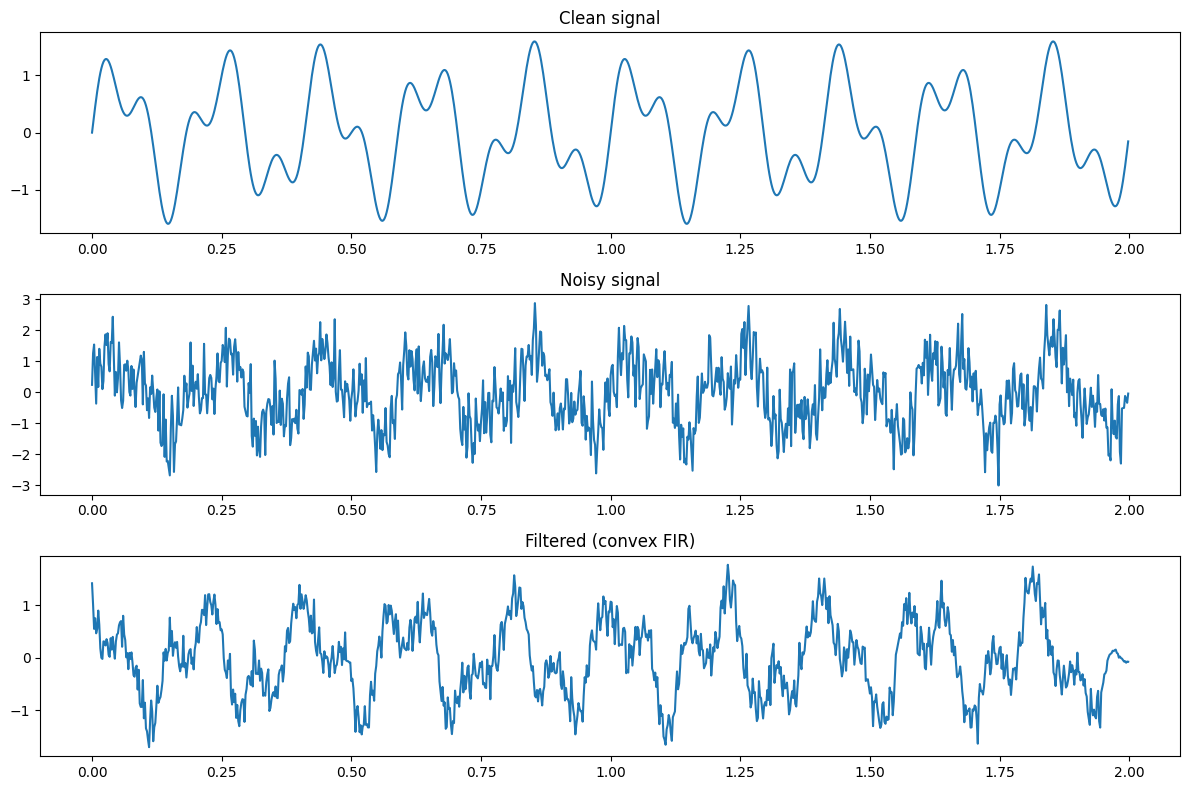

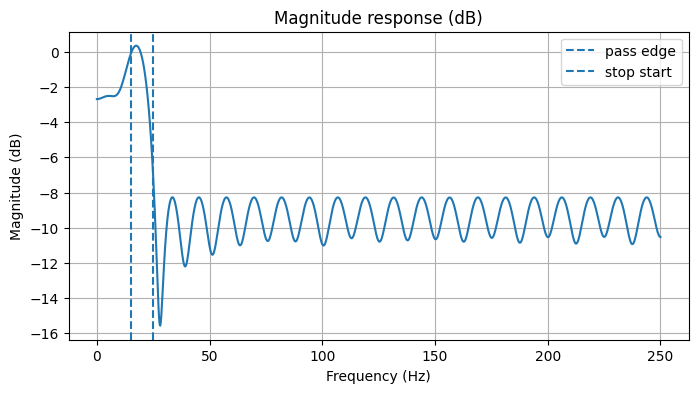

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# ---------------------------
# Synthetic signal (same as you used)
# ---------------------------
fs = 500
T = 2
t = np.linspace(0, T, int(fs*T), endpoint=False)
x_clean = 1.0*np.sin(2*np.pi*5*t) + 0.6*np.sin(2*np.pi*12*t)
noise = 0.5*np.sin(2*np.pi*80*t) + 0.5*np.random.randn(len(t))
x_noisy = x_clean + noise

# ---------------------------
# Parameters for FIR design
# ---------------------------
N = 41  # filter length (odd)
h = cp.Variable(N)  # real-valued coefficients

# Frequency grid for constraints
n_freq = 512
w = np.linspace(0, np.pi, n_freq)

# Define passband and stopband in Hz
f_pass = 15
f_stop = 25
w_pass = 2*np.pi*f_pass/fs
w_stop = 2*np.pi*f_stop/fs

# Select indices for passband / stopband constraints
pass_idx = np.where(w <= w_pass)[0]
stop_idx = np.where(w >= w_stop)[0]

# Slack variables for passband ripple and stopband level
delta_p = cp.Variable(nonneg=True)
delta_s = cp.Variable(nonneg=True)

# Build Re(H) and Im(H) as linear forms in h for each frequency
# Re(H(w)) = sum_n h[n] * cos(w*n)
# Im(H(w)) = - sum_n h[n] * sin(w*n)  (because e^{-jwn} = cos - j sin)

n = np.arange(N)

constraints = []

for idx in pass_idx:
    wi = w[idx]
    re_coeffs = np.cos(wi * n)       # 1 x N
    im_coeffs = -np.sin(wi * n)      # 1 x N
    re_expr = h @ re_coeffs
    im_expr = h @ im_coeffs
    # || [Re(H)-1, Im(H)] ||_2 <= delta_p
    constraints.append(cp.norm(cp.hstack([re_expr - 1.0, im_expr]), 2) <= delta_p)

for idx in stop_idx:
    wi = w[idx]
    re_coeffs = np.cos(wi * n)
    im_coeffs = -np.sin(wi * n)
    re_expr = h @ re_coeffs
    im_expr = h @ im_coeffs
    # || [Re(H), Im(H)] ||_2 <= delta_s
    constraints.append(cp.norm(cp.hstack([re_expr, im_expr]), 2) <= delta_s)

# Optionally constrain delta_s to be small and delta_p small; or minimize their weighted sum
# Objective: minimize max(delta_p, alpha*delta_s) or simple weighted sum
alpha = 1.0  # weight between passband ripple and stopband attenuation
objective = cp.Minimize(delta_p + alpha * delta_s)

prob = cp.Problem(objective, constraints)
prob.solve(verbose=True)   # use default solver; verbose helps debugging

print("Status:", prob.status)
print("delta_p (pass ripple) = ", delta_p.value)
print("delta_s (stopband level)= ", delta_s.value)

h_opt = h.value

# ---------------------------
# Filter the noisy signal
# ---------------------------
y_filtered = np.convolve(x_noisy, h_opt, mode='same')

# ---------------------------
# Plot time-domain signals
# ---------------------------
plt.figure(figsize=(12, 8))
plt.subplot(3,1,1); plt.plot(t, x_clean); plt.title("Clean signal")
plt.subplot(3,1,2); plt.plot(t, x_noisy); plt.title("Noisy signal")
plt.subplot(3,1,3); plt.plot(t, y_filtered); plt.title("Filtered (convex FIR)")
plt.tight_layout(); plt.show()

# ---------------------------
# Frequency response
# ---------------------------
w_resp = np.linspace(0, np.pi, 1024)
H_resp = np.array([np.dot(h_opt, np.exp(-1j*wi*n)) for wi in w_resp])
freq_hz = w_resp * fs/(2*np.pi)
plt.figure(figsize=(8,4))
plt.plot(freq_hz, 20*np.log10(np.abs(H_resp) + 1e-9))
plt.axvline(f_pass, linestyle='--', label='pass edge')
plt.axvline(f_stop, linestyle='--', label='stop start')
plt.title("Magnitude response (dB)")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude (dB)")
plt.legend(); plt.grid(True); plt.show()



Epoch 0, Loss = 1.512640
Epoch 10, Loss = 1.128406
Epoch 20, Loss = 0.824821
Epoch 30, Loss = 0.596677
Epoch 40, Loss = 0.432576


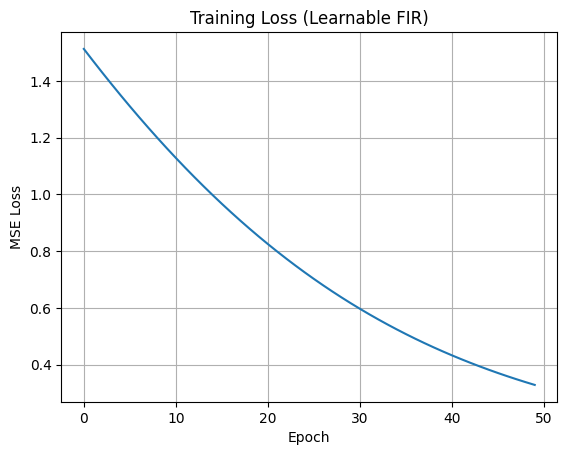

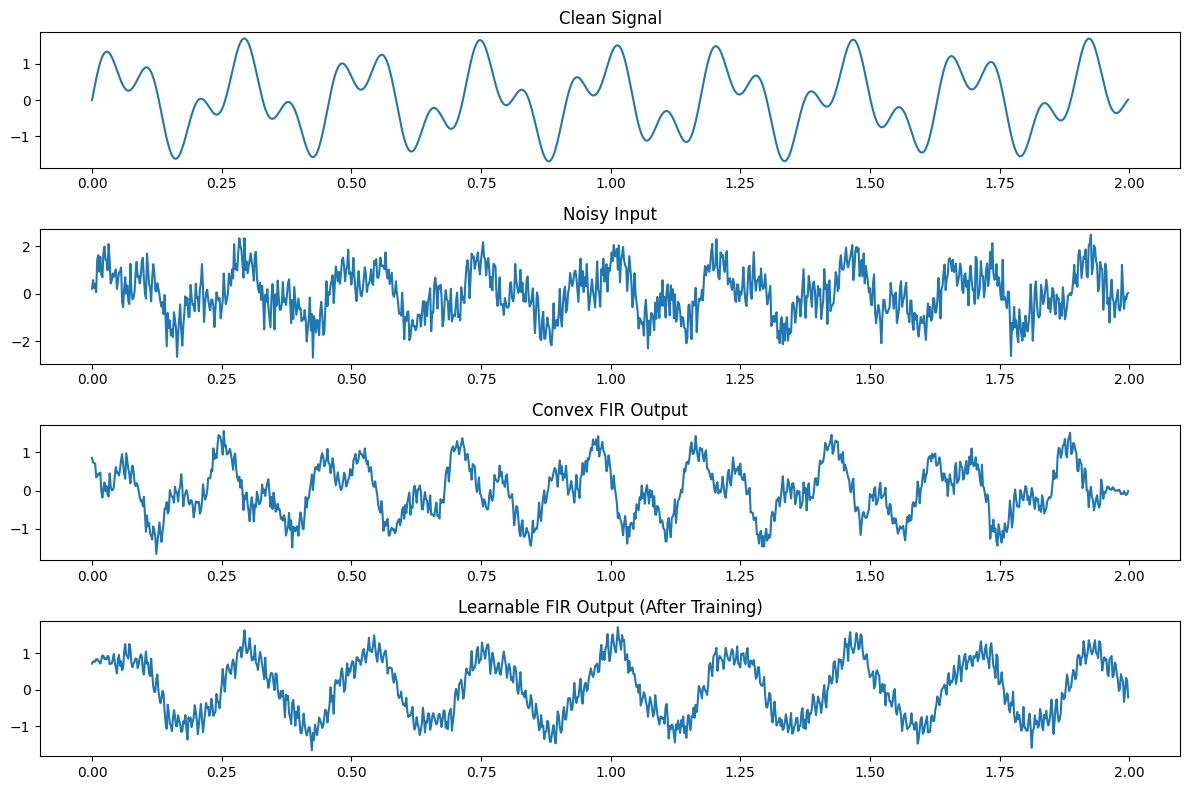

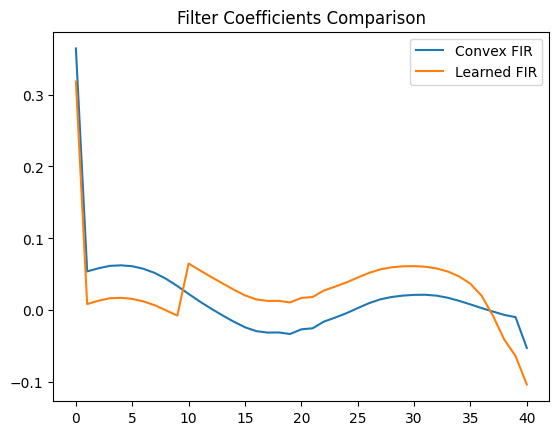

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
# h_opt = ...     # <-- load your convex-optimal FIR from Phase 1
h_torch = torch.tensor(h_opt, dtype=torch.float32).view(1, 1, -1)
class LearnableFIR(nn.Module):
    def __init__(self, h_init):
        super().__init__()
        N = h_init.shape[-1]
        self.conv = nn.Conv1d(1, 1, kernel_size=N, padding=N//2, bias=False)
        self.conv.weight.data = h_init   # initialize with convex filter

    def forward(self, x):
        return self.conv(x)
def generate_signals(num=200, fs=500, T=2):
    t = np.linspace(0, T, int(fs*T), endpoint=False)
    clean_list = []
    noisy_list = []

    for _ in range(num):
        # random low frequency components
        f1 = np.random.uniform(4, 8)
        f2 = np.random.uniform(10, 14)
        clean = np.sin(2*np.pi*f1*t) + 0.7*np.sin(2*np.pi*f2*t)

        # noise (hf + Gaussian)
        noise = 0.4*np.sin(2*np.pi*np.random.uniform(60, 100)*t)
        noise += 0.4*np.random.randn(len(t))

        noisy = clean + noise

        clean_list.append(clean)
        noisy_list.append(noisy)

    clean_arr = np.array(clean_list)
    noisy_arr = np.array(noisy_list)
    return clean_arr, noisy_arr, t

clean_arr, noisy_arr, t = generate_signals()
X = torch.tensor(noisy_arr, dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(clean_arr, dtype=torch.float32).unsqueeze(1)
model = LearnableFIR(h_torch)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

epochs = 50
loss_list = []

for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
plt.plot(loss_list)
plt.title("Training Loss (Learnable FIR)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()
idx = 0  # test on first sample
noisy = X[idx].detach().numpy().flatten()
clean = Y[idx].detach().numpy().flatten()

with torch.no_grad():
    learned_out = model(X[idx:idx+1]).numpy().flatten()

# Convex filter output (for comparison)
convex_out = np.convolve(noisy, h_opt, mode='same')
plt.figure(figsize=(12, 8))

plt.subplot(4,1,1)
plt.plot(t, clean)
plt.title("Clean Signal")

plt.subplot(4,1,2)
plt.plot(t, noisy)
plt.title("Noisy Input")

plt.subplot(4,1,3)
plt.plot(t, convex_out)
plt.title("Convex FIR Output")

plt.subplot(4,1,4)
plt.plot(t, learned_out)
plt.title("Learnable FIR Output (After Training)")

plt.tight_layout()
plt.show()
learned_filter = model.conv.weight.data.numpy().flatten()

plt.plot(h_opt, label="Convex FIR")
plt.plot(learned_filter, label="Learned FIR")
plt.legend()
plt.title("Filter Coefficients Comparison")
plt.show()


(CVXPY) Dec 25 07:05:14 AM: Your problem has 43 variables, 511 constraints, and 0 parameters.
(CVXPY) Dec 25 07:05:14 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Dec 25 07:05:14 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Dec 25 07:05:14 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Dec 25 07:05:14 AM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.6.7                                    


(CVXPY) Dec 25 07:05:14 AM: Compiling problem (target solver=CLARABEL).
(CVXPY) Dec 25 07:05:14 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Dec 25 07:05:14 AM: Applying reduction Dcp2Cone
(CVXPY) Dec 25 07:05:14 AM: Applying reduction CvxAttr2Constr


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Dec 25 07:05:14 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Dec 25 07:05:15 AM: Applying reduction CLARABEL
(CVXPY) Dec 25 07:05:17 AM: Finished problem compilation (took 3.346e+00 seconds).
(CVXPY) Dec 25 07:05:17 AM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 534
  constraints   = 1986
  nnz(P)        = 0
  nnz(A)        = 41246
  cones (total) = 493
    :        Zero = 1,  numel = 20
    : Nonnegative = 1,  numel = 493
    : SecondOrder = 491,  numel = (3,3,3,3,...,3)

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static r

(CVXPY) Dec 25 07:05:18 AM: Problem status: optimal
(CVXPY) Dec 25 07:05:18 AM: Optimal value: 1.000e+00
(CVXPY) Dec 25 07:05:18 AM: Compilation took 3.346e+00 seconds
(CVXPY) Dec 25 07:05:18 AM: Solver (including time spent in interface) took 2.568e-01 seconds


 12  +1.0000e+00  +1.0000e+00  5.54e-13  9.03e-11  2.78e-10  2.80e-13  7.86e-11  9.79e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 224.863096ms
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal
delta_p (passband ripple) = 0.9999999999963614
delta_s (stopband level)  = 2.740169050901712e-11


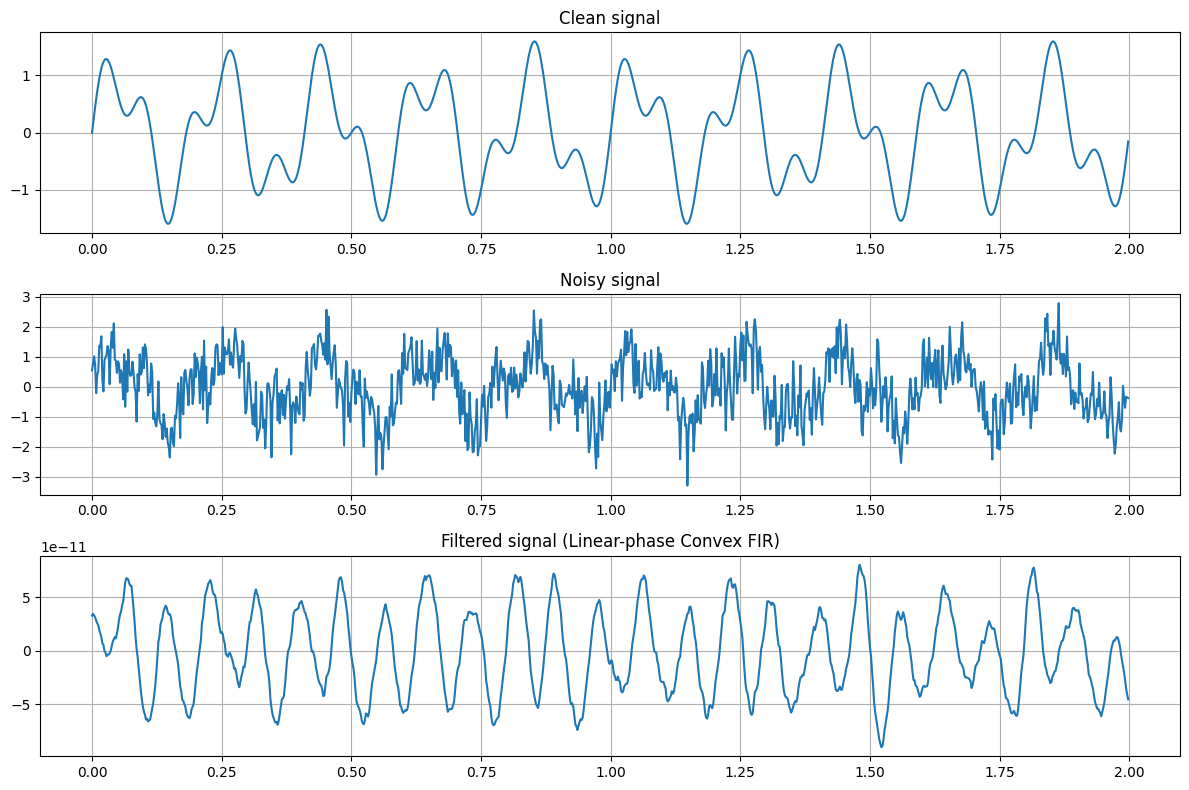

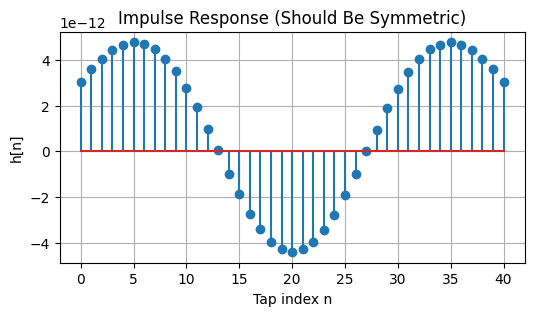

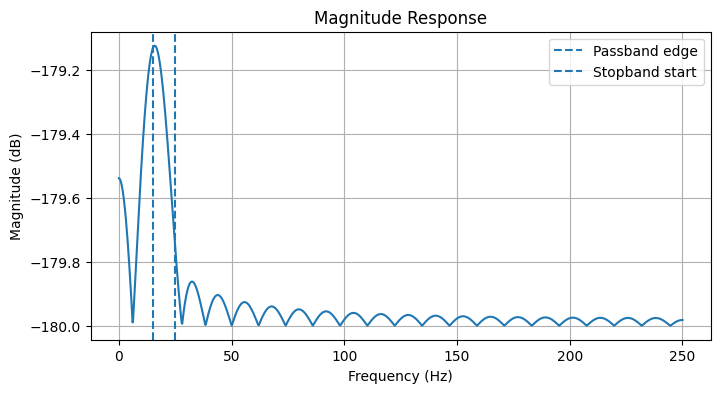

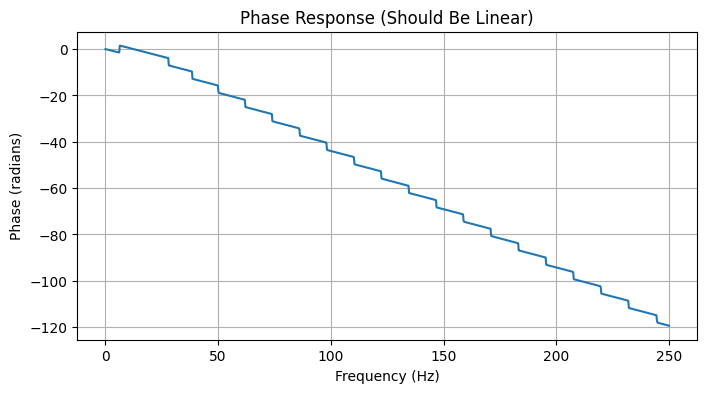

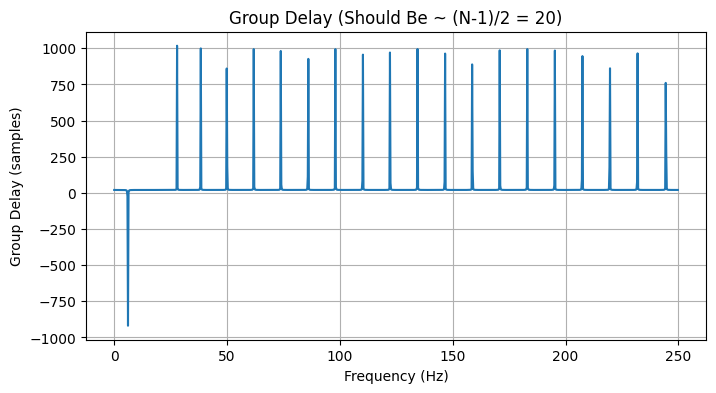

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# ============================================================
# 1. Signal generation
# ============================================================
fs = 500          # sampling frequency (Hz)
T = 2             # duration (seconds)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Clean low-frequency signal
x_clean = 1.0*np.sin(2*np.pi*5*t) + 0.6*np.sin(2*np.pi*12*t)

# High-frequency noise + random noise
noise = 0.5*np.sin(2*np.pi*80*t) + 0.5*np.random.randn(len(t))
x_noisy = x_clean + noise


# ============================================================
# 2. FIR filter parameters
# ============================================================
N = 41                    # FIR tap length (odd for linear phase)
h = cp.Variable(N)        # FIR coefficients (optimization variable)

# Frequency grid
n_freq = 512
w = np.linspace(0, np.pi, n_freq)

# Passband and stopband edges (Hz)
f_pass = 15
f_stop = 25

# Convert to rad/sample
w_pass = 2*np.pi*f_pass/fs
w_stop = 2*np.pi*f_stop/fs

# Indices for passband and stopband
pass_idx = np.where(w <= w_pass)[0]
stop_idx = np.where(w >= w_stop)[0]

# Slack variables (ripple and attenuation)
delta_p = cp.Variable(nonneg=True)   # passband ripple
delta_s = cp.Variable(nonneg=True)   # stopband level

# Tap indices
n = np.arange(N)

constraints = []

# ============================================================
# 3. Linear-phase (symmetry) constraints
# ============================================================
# Enforce h[n] = h[N-1-n]
for i in range(N // 2):
    constraints.append(h[i] == h[N - 1 - i])


# ============================================================
# 4. Frequency-domain constraints
# ============================================================

# Passband: |H(w) - 1| <= delta_p
for idx in pass_idx:
    wi = w[idx]
    re_expr = h @ np.cos(wi * n)
    im_expr = h @ (-np.sin(wi * n))
    constraints.append(
        cp.norm(cp.hstack([re_expr - 1.0, im_expr]), 2) <= delta_p
    )

# Stopband: |H(w)| <= delta_s
for idx in stop_idx:
    wi = w[idx]
    re_expr = h @ np.cos(wi * n)
    im_expr = h @ (-np.sin(wi * n))
    constraints.append(
        cp.norm(cp.hstack([re_expr, im_expr]), 2) <= delta_s
    )


# ============================================================
# 5. Optimization objective
# ============================================================
alpha = 1.0   # weight between passband ripple and stopband attenuation
objective = cp.Minimize(delta_p + alpha * delta_s)

prob = cp.Problem(objective, constraints)
prob.solve(verbose=True)

print("Status:", prob.status)
print("delta_p (passband ripple) =", delta_p.value)
print("delta_s (stopband level)  =", delta_s.value)

h_opt = h.value


# ============================================================
# 6. Apply FIR filter
# ============================================================
y_filtered = np.convolve(x_noisy, h_opt, mode='same')


# ============================================================
# 7. Time-domain plots
# ============================================================
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, x_clean)
plt.title("Clean signal")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, x_noisy)
plt.title("Noisy signal")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, y_filtered)
plt.title("Filtered signal (Linear-phase Convex FIR)")
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 8. Impulse response (symmetry check)
# ============================================================
plt.figure(figsize=(6, 3))
plt.stem(h_opt)
plt.title("Impulse Response (Should Be Symmetric)")
plt.xlabel("Tap index n")
plt.ylabel("h[n]")
plt.grid(True)
plt.show()


# ============================================================
# 9. Frequency response
# ============================================================
w_resp = np.linspace(0, np.pi, 1024)
H_resp = np.array([np.dot(h_opt, np.exp(-1j * wi * n)) for wi in w_resp])
freq_hz = w_resp * fs / (2*np.pi)

plt.figure(figsize=(8, 4))
plt.plot(freq_hz, 20*np.log10(np.abs(H_resp) + 1e-9))
plt.axvline(f_pass, linestyle='--', label='Passband edge')
plt.axvline(f_stop, linestyle='--', label='Stopband start')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Magnitude Response")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 10. Phase response (linear-phase check)
# ============================================================
phase = np.unwrap(np.angle(H_resp))
plt.figure(figsize=(8, 4))
plt.plot(freq_hz, phase)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
plt.title("Phase Response (Should Be Linear)")
plt.grid(True)
plt.show()


# ============================================================
# 11. Group delay (optional, verification)
# ============================================================
group_delay = -np.diff(phase) / np.diff(w_resp)
plt.figure(figsize=(8, 4))
plt.plot(freq_hz[:-1], group_delay)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Group Delay (samples)")
plt.title("Group Delay (Should Be ~ (N-1)/2 = {})".format((N-1)//2))
plt.grid(True)
plt.show()


In [7]:
from scipy.signal import butter, filtfilt, freqz

fs = 500        # sampling frequency (Hz)
order = 4
fc = 15         # cutoff frequency (Hz)

Wn = fc / (fs / 2)   # normalized cutoff (Nyquist = fs/2)

# Design Butterworth filter
b_bw, a_bw = butter(order, Wn, btype='low', analog=False)

# Apply zero-phase filtering (important for fair comparison)
y_bw = filtfilt(b_bw, a_bw, x_noisy)


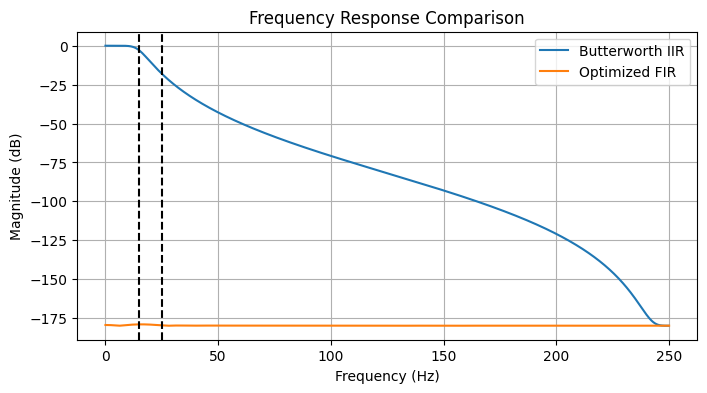

In [8]:
# Frequency response of Butterworth
w_bw, H_bw = freqz(b_bw, a_bw, worN=1024)
freq_bw = w_bw * fs / (2*np.pi)

plt.figure(figsize=(8,4))
plt.plot(freq_bw, 20*np.log10(np.abs(H_bw) + 1e-9), label='Butterworth IIR')
plt.plot(freq_hz, 20*np.log10(np.abs(H_resp) + 1e-9), label='Optimized FIR')
plt.axvline(15, linestyle='--', color='k')
plt.axvline(25, linestyle='--', color='k')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Response Comparison")
plt.legend()
plt.grid(True)
plt.show()


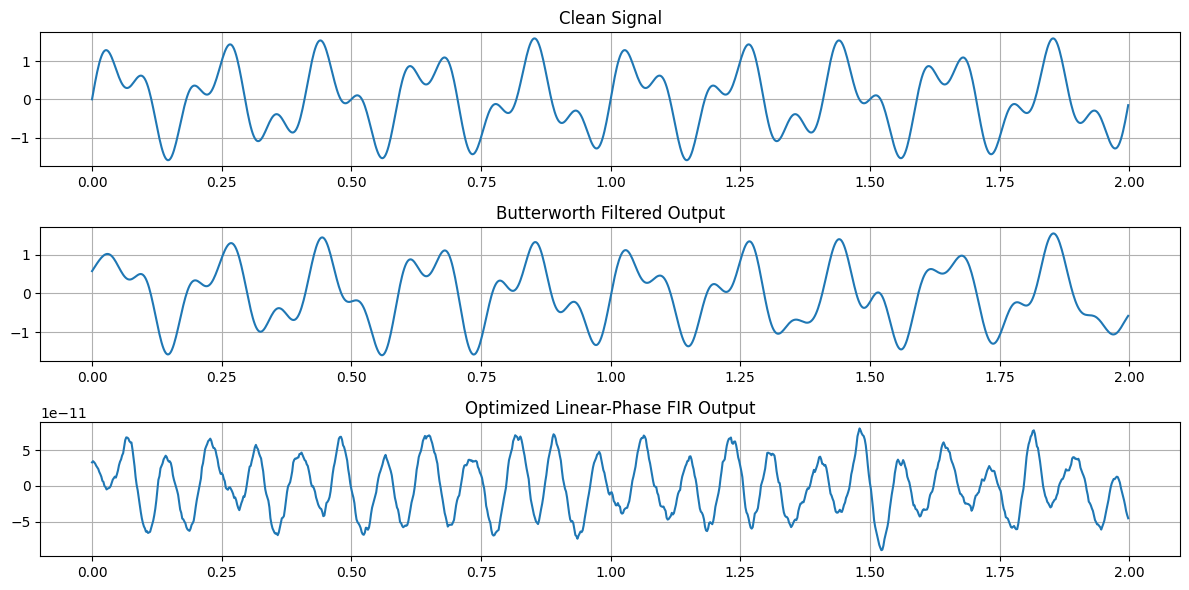

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(3,1,1)
plt.plot(t, x_clean)
plt.title("Clean Signal")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, y_bw)
plt.title("Butterworth Filtered Output")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, y_filtered)
plt.title("Optimized Linear-Phase FIR Output")
plt.grid(True)

plt.tight_layout()
plt.show()


In [10]:
mse_bw = np.mean((y_bw - x_clean)**2)
mse_fir = np.mean((y_filtered - x_clean)**2)

print("MSE Butterworth:", mse_bw)
print("MSE Optimized FIR:", mse_fir)


MSE Butterworth: 0.023925443397497023
MSE Optimized FIR: 0.6800000000110348


Epoch   0 | Loss = 0.680000
Epoch  20 | Loss = 0.246395
Epoch  40 | Loss = 0.085211
Epoch  60 | Loss = 0.039418
Epoch  80 | Loss = 0.029047
Epoch 100 | Loss = 0.026308
Epoch 120 | Loss = 0.025087
Epoch 140 | Loss = 0.024348
Epoch 160 | Loss = 0.023772
Epoch 180 | Loss = 0.023281


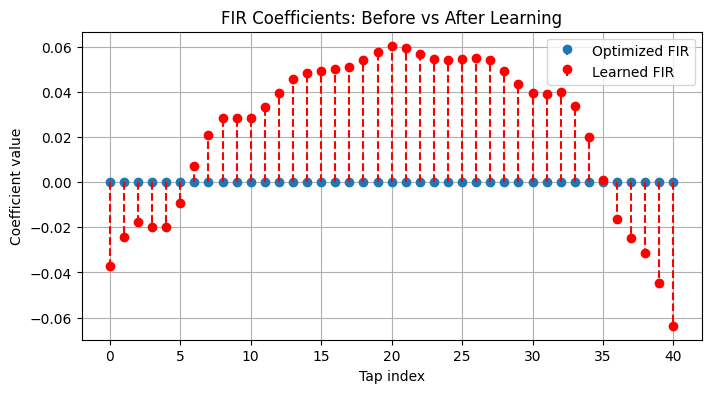

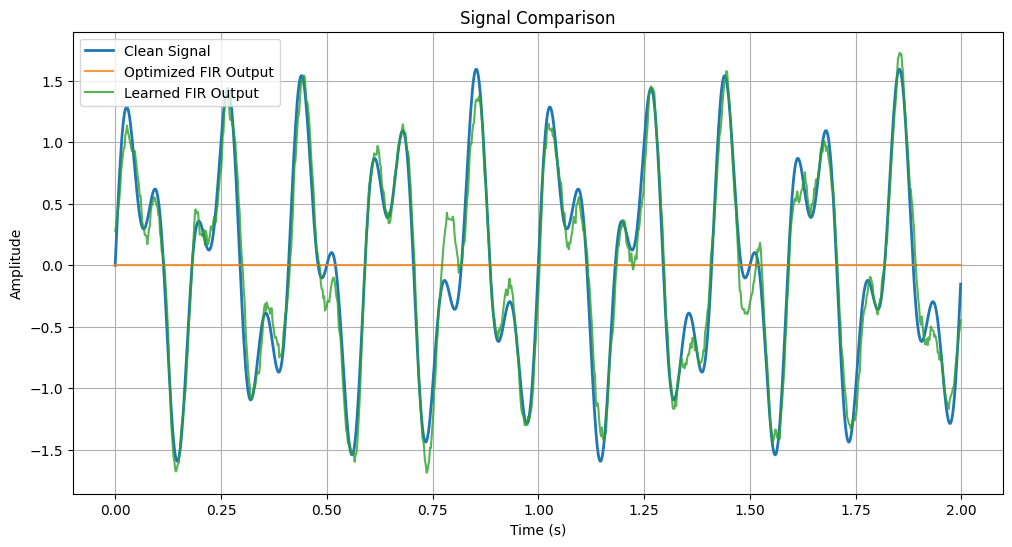

MSE Optimized FIR : 0.6800000000110348
MSE Learned FIR   : 0.030190621525181347


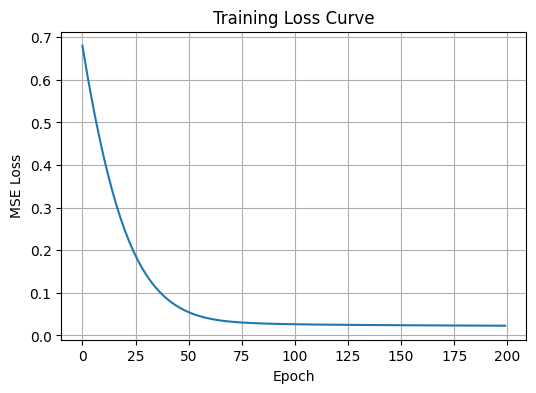

In [11]:
# ============================================================
# STEP 4: Learnable FIR Filter using PyTorch
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare training data
# ------------------------------------------------------------
# Shape required by Conv1D: (batch, channels, signal_length)

x_train = torch.tensor(x_noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
y_train = torch.tensor(x_clean, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


# ------------------------------------------------------------
# 2. Define Learnable FIR Filter Model
# ------------------------------------------------------------
class LearnableFIR(nn.Module):
    def __init__(self, h_init):
        super().__init__()
        N = len(h_init)

        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=N,
            padding=N // 2,
            bias=False
        )

        # Initialize with optimized FIR coefficients
        with torch.no_grad():
            self.conv.weight[:] = (
                torch.tensor(h_init, dtype=torch.float32)
                .view(1, 1, -1)
            )

    def forward(self, x):
        return self.conv(x)


# ------------------------------------------------------------
# 3. Initialize model, loss, optimizer
# ------------------------------------------------------------
model = LearnableFIR(h_opt)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# ------------------------------------------------------------
# 4. Training loop
# ------------------------------------------------------------
num_epochs = 200
loss_history = []

for epoch in range(num_epochs):
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss = {loss.item():.6f}")


# ------------------------------------------------------------
# 5. Extract learned FIR coefficients
# ------------------------------------------------------------
h_learned = model.conv.weight.detach().cpu().numpy().reshape(-1)


# ------------------------------------------------------------
# 6. Filter noisy signal using learned FIR
# ------------------------------------------------------------
y_learned = np.convolve(x_noisy, h_learned, mode='same')


# ------------------------------------------------------------
# 7. Compare impulse responses
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.stem(h_opt, label='Optimized FIR', basefmt=" ")
plt.stem(h_learned, linefmt='r--', markerfmt='ro', label='Learned FIR', basefmt=" ")
plt.title("FIR Coefficients: Before vs After Learning")
plt.xlabel("Tap index")
plt.ylabel("Coefficient value")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 8. Time-domain comparison
# ------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(t, x_clean, label='Clean Signal', linewidth=2)
plt.plot(t, y_filtered, label='Optimized FIR Output', alpha=0.8)
plt.plot(t, y_learned, label='Learned FIR Output', alpha=0.8)
plt.legend()
plt.title("Signal Comparison")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 9. Error comparison
# ------------------------------------------------------------
mse_opt = np.mean((y_filtered - x_clean)**2)
mse_learned = np.mean((y_learned - x_clean)**2)

print("MSE Optimized FIR :", mse_opt)
print("MSE Learned FIR   :", mse_learned)


# ------------------------------------------------------------
# 10. Training loss curve
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


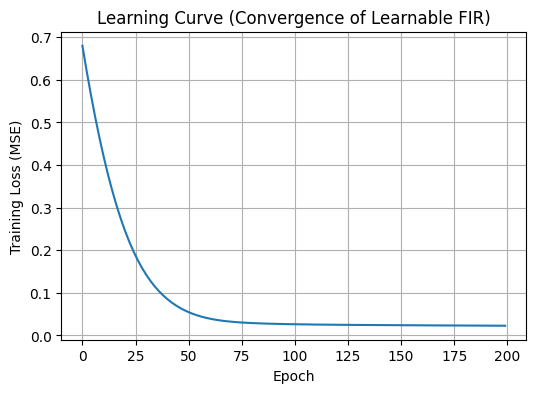

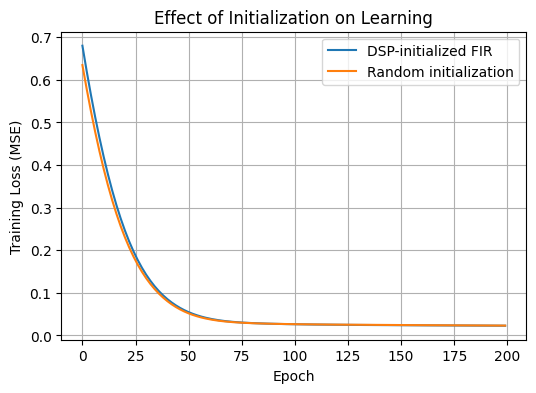

MSE on unseen noisy signal: 0.02171161152148584


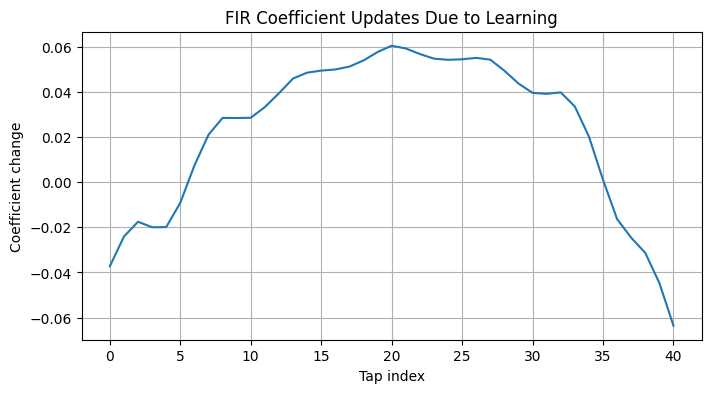

In [12]:
# ============================================================
# STEP 5: ML-Centric Evaluation (Single Cell)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

# ------------------------------------------------------------
# 5.1 Learning curve (convergence analysis)
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Learning Curve (Convergence of Learnable FIR)")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 5.2 Initialization study (DSP init vs Random init)
# ------------------------------------------------------------
# Randomly initialized FIR
model_rand = LearnableFIR(np.random.randn(len(h_opt)) * 0.01)
optimizer_rand = optim.Adam(model_rand.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

loss_rand = []
num_epochs = len(loss_history)

for epoch in range(num_epochs):
    optimizer_rand.zero_grad()
    y_pred = model_rand(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer_rand.step()
    loss_rand.append(loss.item())

plt.figure(figsize=(6,4))
plt.plot(loss_history, label="DSP-initialized FIR")
plt.plot(loss_rand, label="Random initialization")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Effect of Initialization on Learning")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 5.3 Generalization test on unseen noisy data
# ------------------------------------------------------------
noise_new = 0.5*np.sin(2*np.pi*80*t) + 0.5*np.random.randn(len(t))
x_noisy_new = x_clean + noise_new

y_learned_new = np.convolve(x_noisy_new, h_learned, mode='same')
mse_new = np.mean((y_learned_new - x_clean)**2)

print("MSE on unseen noisy signal:", mse_new)


# ------------------------------------------------------------
# 5.4 Parameter update analysis (what did ML learn?)
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(h_learned - h_opt)
plt.xlabel("Tap index")
plt.ylabel("Coefficient change")
plt.title("FIR Coefficient Updates Due to Learning")
plt.grid(True)
plt.show()


✔ Learnable FIR model saved as learnable_fir_model.pth
✔ Learned FIR coefficients saved as learned_fir_coefficients.npy
✔ Model successfully reloaded


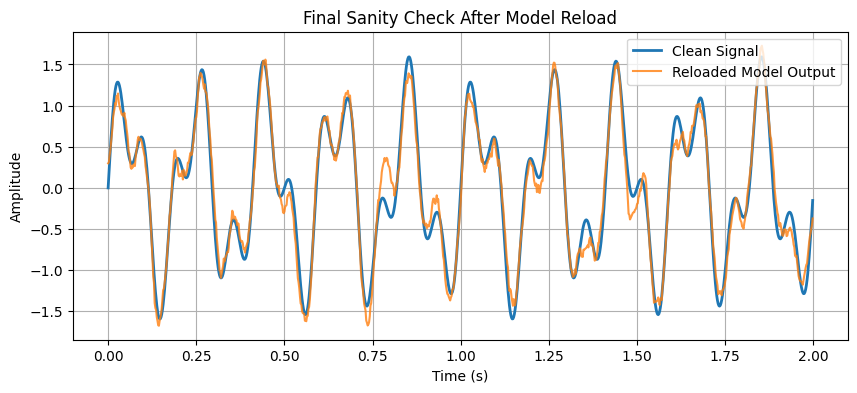

Final MSE after reload: 0.02285487172470701


In [14]:
# ============================================================
# STEP 6: Finalization & Deployment (Single Cell)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 6.1 Save trained model and learned FIR coefficients
# ------------------------------------------------------------
torch.save(model.state_dict(), "learnable_fir_model.pth")
np.save("learned_fir_coefficients.npy", h_learned)

print("✔ Learnable FIR model saved as learnable_fir_model.pth")
print("✔ Learned FIR coefficients saved as learned_fir_coefficients.npy")


# ------------------------------------------------------------
# 6.2 Reload model (deployment-style check)
# ------------------------------------------------------------
model_loaded = LearnableFIR(h_opt)
model_loaded.load_state_dict(torch.load("learnable_fir_model.pth"))
model_loaded.eval()

print("✔ Model successfully reloaded")


# ------------------------------------------------------------
# 6.3 Sanity check after reload (inference)
# ------------------------------------------------------------
with torch.no_grad():
    y_reload = model_loaded(x_train).numpy().reshape(-1)

plt.figure(figsize=(10,4))
plt.plot(t, x_clean, label="Clean Signal", linewidth=2)
plt.plot(t, y_reload, label="Reloaded Model Output", alpha=0.8)
plt.legend()
plt.title("Final Sanity Check After Model Reload")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 6.4 Final performance confirmation
# ------------------------------------------------------------
mse_reload = np.mean((y_reload - x_clean)**2)
print("Final MSE after reload:", mse_reload)



In [15]:
# ============================================================
# METRICS EVALUATION (ML-STYLE)
# ============================================================

import numpy as np

# --- Metric functions ---
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def snr(signal, noise):
    return 10 * np.log10(np.sum(signal**2) / np.sum(noise**2))

# --- Baselines ---
mse_noisy = mse(x_clean, x_noisy)
mse_opt = mse(x_clean, y_filtered)
mse_learned = mse(x_clean, y_learned)

snr_noisy = snr(x_clean, x_noisy - x_clean)
snr_opt = snr(x_clean, y_filtered - x_clean)
snr_learned = snr(x_clean, y_learned - x_clean)

# --- Display results ---
print("========== METRICS EVALUATION ==========")
print(f"MSE  | Noisy Signal     : {mse_noisy:.6f}")
print(f"MSE  | Optimized FIR   : {mse_opt:.6f}")
print(f"MSE  | Learned FIR     : {mse_learned:.6f}")
print("----------------------------------------")
print(f"SNR  | Noisy Signal     : {snr_noisy:.2f} dB")
print(f"SNR  | Optimized FIR   : {snr_opt:.2f} dB")
print(f"SNR  | Learned FIR     : {snr_learned:.2f} dB")
print("========================================")


========== METRICS EVALUATION ==========
MSE  | Noisy Signal     : 0.384339
MSE  | Optimized FIR   : 0.680000
MSE  | Learned FIR     : 0.030191
----------------------------------------
SNR  | Noisy Signal     : 2.48 dB
SNR  | Optimized FIR   : -0.00 dB
SNR  | Learned FIR     : 13.53 dB
